In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first five rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1470, 35)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    i

In [8]:
# Distribution of the target variable
print(df['Attrition'].value_counts())

# Percentage
print("\nPercentage:")
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [9]:
# Drop columns that do not help prediction
df = df.drop(['EmployeeCount',
              'EmployeeNumber',
              'Over18',
              'StandardHours'], axis=1)

print("New Shape:", df.shape)

New Shape: (1470, 31)


In [10]:
# Convert categorical columns into numerical values
df = pd.get_dummies(df, drop_first=True)

print("New Shape:", df.shape)
df.head()

New Shape: (1470, 45)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [11]:
# Separate input features and target variable
X = df.drop("Attrition_Yes", axis=1)
y = df["Attrition_Yes"].astype(int)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (1470, 44)
Target shape: (1470,)

Target distribution:
Attrition_Yes
0    1233
1     237
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1176, 44)
Testing Features : (294, 44)
Training Labels  : (1176,)
Testing Labels   : (294,)


In [13]:
!pip install xgboost

In [14]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression with feature scaling
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Scaled Logistic Regression Results")
print("----------------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

Scaled Logistic Regression Results
----------------------------------
Accuracy : 0.8605
Precision: 0.6154
Recall   : 0.3404
F1 Score : 0.4384
ROC-AUC  : 0.8079


In [16]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.8333
Precision: 0.4167
Recall   : 0.1064
F1 Score : 0.1695
ROC-AUC  : 0.7862


In [17]:
# Train XGBoost model

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

XGBoost Results
----------------
Accuracy : 0.8605
Precision: 0.6500
Recall   : 0.2766
F1 Score : 0.3881
ROC-AUC  : 0.7638


In [18]:
!pip install imbalanced-learn


In [19]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [21]:
# Apply SMOTE only to the training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Shape:")
print(X_train.shape, y_train.shape)

print("\nAfter SMOTE:")
print(X_train_smote.shape, y_train_smote.shape)

print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())

Original Training Shape:
(1176, 44) (1176,)

After SMOTE:
(1972, 44) (1972,)

Class Distribution After SMOTE:
Attrition_Yes
0    986
1    986
Name: count, dtype: int64


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression with SMOTE data
lr_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# Train on SMOTE data
lr_smote.fit(X_train_smote, y_train_smote)

# Predict on the ORIGINAL test set
y_pred_lr_smote = lr_smote.predict(X_test)
y_prob_lr_smote = lr_smote.predict_proba(X_test)[:, 1]

# Evaluation
lr_smote_accuracy = accuracy_score(y_test, y_pred_lr_smote)
lr_smote_precision = precision_score(y_test, y_pred_lr_smote)
lr_smote_recall = recall_score(y_test, y_pred_lr_smote)
lr_smote_f1 = f1_score(y_test, y_pred_lr_smote)
lr_smote_auc = roc_auc_score(y_test, y_prob_lr_smote)

print("Logistic Regression + SMOTE Results")
print("-----------------------------------")
print(f"Accuracy : {lr_smote_accuracy:.4f}")
print(f"Precision: {lr_smote_precision:.4f}")
print(f"Recall   : {lr_smote_recall:.4f}")
print(f"F1 Score : {lr_smote_f1:.4f}")
print(f"ROC-AUC  : {lr_smote_auc:.4f}")

Logistic Regression + SMOTE Results
-----------------------------------
Accuracy : 0.8571
Precision: 0.5714
Recall   : 0.4255
F1 Score : 0.4878
ROC-AUC  : 0.7208


In [23]:
# Train Random Forest on SMOTE data

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf_smote = rf_smote.predict(X_test)
y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Evaluation
rf_smote_accuracy = accuracy_score(y_test, y_pred_rf_smote)
rf_smote_precision = precision_score(y_test, y_pred_rf_smote)
rf_smote_recall = recall_score(y_test, y_pred_rf_smote)
rf_smote_f1 = f1_score(y_test, y_pred_rf_smote)
rf_smote_auc = roc_auc_score(y_test, y_prob_rf_smote)

print("Random Forest + SMOTE Results")
print("-----------------------------")
print(f"Accuracy : {rf_smote_accuracy:.4f}")
print(f"Precision: {rf_smote_precision:.4f}")
print(f"Recall   : {rf_smote_recall:.4f}")
print(f"F1 Score : {rf_smote_f1:.4f}")
print(f"ROC-AUC  : {rf_smote_auc:.4f}")

Random Forest + SMOTE Results
-----------------------------
Accuracy : 0.8231
Precision: 0.4000
Recall   : 0.2128
F1 Score : 0.2778
ROC-AUC  : 0.7383


In [24]:
# Train XGBoost on SMOTE data

xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

# Evaluation
xgb_smote_accuracy = accuracy_score(y_test, y_pred_xgb_smote)
xgb_smote_precision = precision_score(y_test, y_pred_xgb_smote)
xgb_smote_recall = recall_score(y_test, y_pred_xgb_smote)
xgb_smote_f1 = f1_score(y_test, y_pred_xgb_smote)
xgb_smote_auc = roc_auc_score(y_test, y_prob_xgb_smote)

print("XGBoost + SMOTE Results")
print("-----------------------")
print(f"Accuracy : {xgb_smote_accuracy:.4f}")
print(f"Precision: {xgb_smote_precision:.4f}")
print(f"Recall   : {xgb_smote_recall:.4f}")
print(f"F1 Score : {xgb_smote_f1:.4f}")
print(f"ROC-AUC  : {xgb_smote_auc:.4f}")

XGBoost + SMOTE Results
-----------------------
Accuracy : 0.8469
Precision: 0.5385
Recall   : 0.2979
F1 Score : 0.3836
ROC-AUC  : 0.7550


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression with Class Weighting
lr_weight = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

# Train on the ORIGINAL training data
lr_weight.fit(X_train, y_train)

# Predictions
y_pred_lr_weight = lr_weight.predict(X_test)
y_prob_lr_weight = lr_weight.predict_proba(X_test)[:, 1]

# Evaluation
lr_weight_accuracy = accuracy_score(y_test, y_pred_lr_weight)
lr_weight_precision = precision_score(y_test, y_pred_lr_weight)
lr_weight_recall = recall_score(y_test, y_pred_lr_weight)
lr_weight_f1 = f1_score(y_test, y_pred_lr_weight)
lr_weight_auc = roc_auc_score(y_test, y_prob_lr_weight)

print("Logistic Regression + Class Weight Results")
print("------------------------------------------")
print(f"Accuracy : {lr_weight_accuracy:.4f}")
print(f"Precision: {lr_weight_precision:.4f}")
print(f"Recall   : {lr_weight_recall:.4f}")
print(f"F1 Score : {lr_weight_f1:.4f}")
print(f"ROC-AUC  : {lr_weight_auc:.4f}")

Logistic Regression + Class Weight Results
------------------------------------------
Accuracy : 0.7517
Precision: 0.3452
Recall   : 0.6170
F1 Score : 0.4427
ROC-AUC  : 0.7983


In [26]:
# Train Random Forest with Class Weighting

rf_weight = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_weight.fit(X_train, y_train)

# Predictions
y_pred_rf_weight = rf_weight.predict(X_test)
y_prob_rf_weight = rf_weight.predict_proba(X_test)[:, 1]

# Evaluation
rf_weight_accuracy = accuracy_score(y_test, y_pred_rf_weight)
rf_weight_precision = precision_score(y_test, y_pred_rf_weight)
rf_weight_recall = recall_score(y_test, y_pred_rf_weight)
rf_weight_f1 = f1_score(y_test, y_pred_rf_weight)
rf_weight_auc = roc_auc_score(y_test, y_prob_rf_weight)

print("Random Forest + Class Weight Results")
print("------------------------------------")
print(f"Accuracy : {rf_weight_accuracy:.4f}")
print(f"Precision: {rf_weight_precision:.4f}")
print(f"Recall   : {rf_weight_recall:.4f}")
print(f"F1 Score : {rf_weight_f1:.4f}")
print(f"ROC-AUC  : {rf_weight_auc:.4f}")

Random Forest + Class Weight Results
------------------------------------
Accuracy : 0.8367
Precision: 0.4444
Recall   : 0.0851
F1 Score : 0.1429
ROC-AUC  : 0.7515


In [27]:
# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 5.189473684210526


In [28]:
# Train XGBoost with Class Weighting

xgb_weight = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_weight.fit(X_train, y_train)

# Predictions
y_pred_xgb_weight = xgb_weight.predict(X_test)
y_prob_xgb_weight = xgb_weight.predict_proba(X_test)[:, 1]

# Evaluation
xgb_weight_accuracy = accuracy_score(y_test, y_pred_xgb_weight)
xgb_weight_precision = precision_score(y_test, y_pred_xgb_weight)
xgb_weight_recall = recall_score(y_test, y_pred_xgb_weight)
xgb_weight_f1 = f1_score(y_test, y_pred_xgb_weight)
xgb_weight_auc = roc_auc_score(y_test, y_prob_xgb_weight)

print("XGBoost + Class Weight Results")
print("------------------------------")
print(f"Accuracy : {xgb_weight_accuracy:.4f}")
print(f"Precision: {xgb_weight_precision:.4f}")
print(f"Recall   : {xgb_weight_recall:.4f}")
print(f"F1 Score : {xgb_weight_f1:.4f}")
print(f"ROC-AUC  : {xgb_weight_auc:.4f}")

XGBoost + Class Weight Results
------------------------------
Accuracy : 0.8401
Precision: 0.5000
Recall   : 0.3191
F1 Score : 0.3896
ROC-AUC  : 0.7368


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

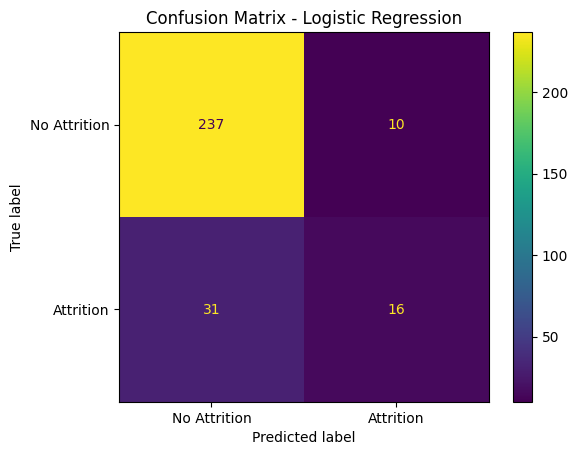

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["No Attrition", "Attrition"],
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

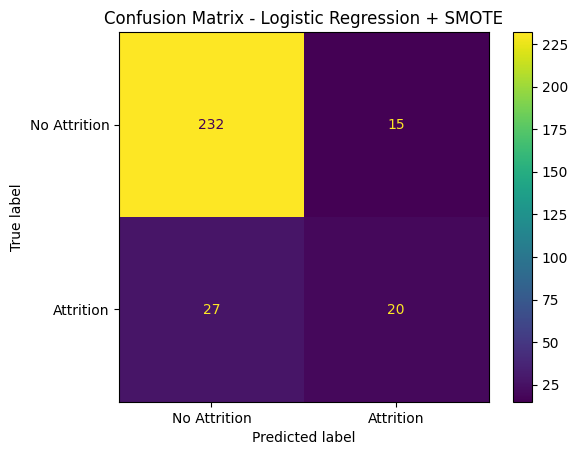

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_smote,
    display_labels=["No Attrition", "Attrition"],
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression + SMOTE")
plt.show()

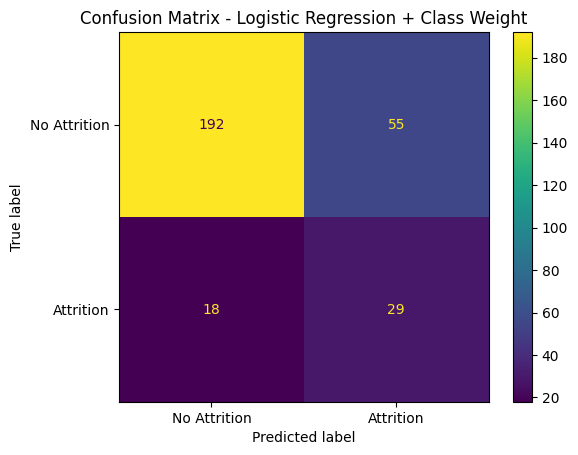

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_weight,
    display_labels=["No Attrition", "Attrition"],
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression + Class Weight")
plt.show()

In [33]:
import pandas as pd

# Get feature names
feature_names = X.columns

# Get Logistic Regression coefficients
coefficients = lr_model.named_steps["classifier"].coef_[0]

# Create a DataFrame
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute importance
importance["Absolute"] = importance["Coefficient"].abs()

# Sort
importance = importance.sort_values("Absolute", ascending=False)

# Show top 15
importance.head(15)

,Feature,Coefficient,Absolute
43,OverTime_Yes,0.864567,0.864567
23,BusinessTravel_Travel_Frequently,0.751247,0.751247
34,JobRole_Laboratory Technician,0.714756,0.714756
16,TotalWorkingYears,-0.555603,0.555603
21,YearsSinceLastPromotion,0.528704,0.528704
11,NumCompaniesWorked,0.487609,0.487609
4,EnvironmentSatisfaction,-0.481659,0.481659
40,JobRole_Sales Representative,0.481459,0.481459
24,BusinessTravel_Travel_Rarely,0.450070,0.450070
8,JobSatisfaction,-0.419417,0.419417


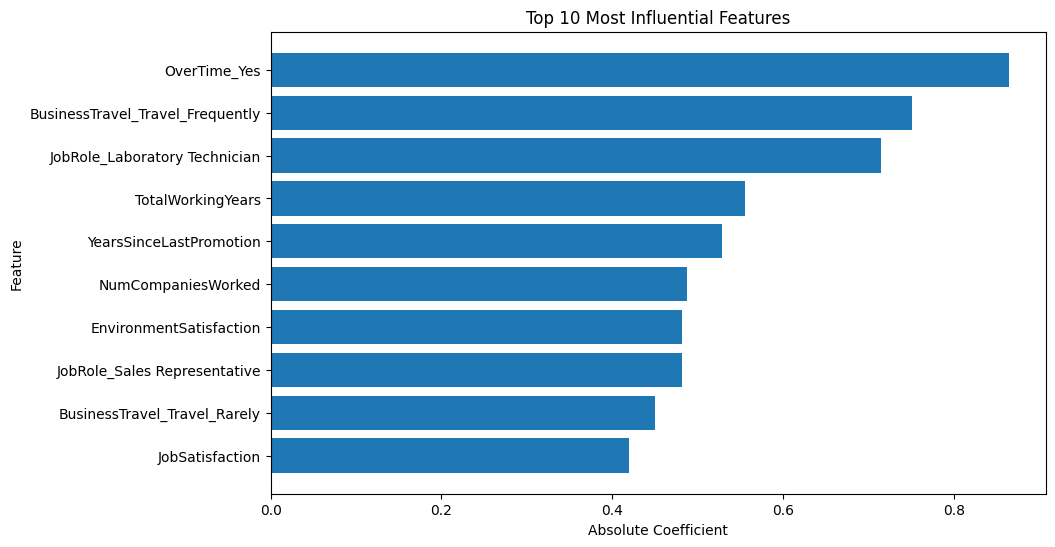

In [34]:
# Top 10 important features
top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Absolute"])
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features")
plt.gca().invert_yaxis()

plt.show()

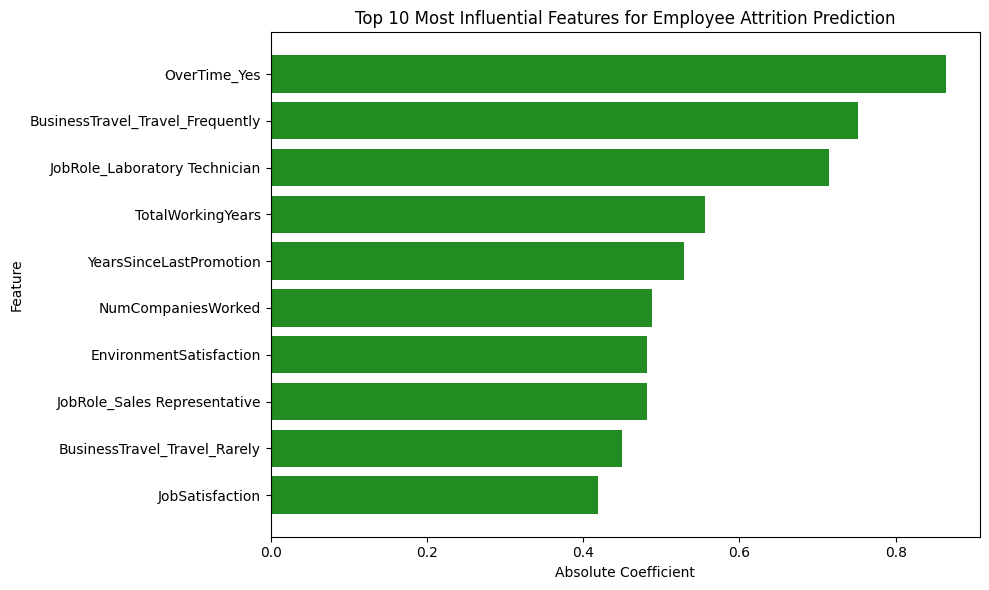

In [35]:
plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Absolute"], color="forestgreen")

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features for Employee Attrition Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()